In [43]:
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet
from spidercat.circuit_extraction import extract_circuit_rooted

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{2: [(1, 2)], 3: [(2, 3)], 6: [(6, 8), (6, 9)], 8: [(3, 8)], 9: [(4, 9)]}


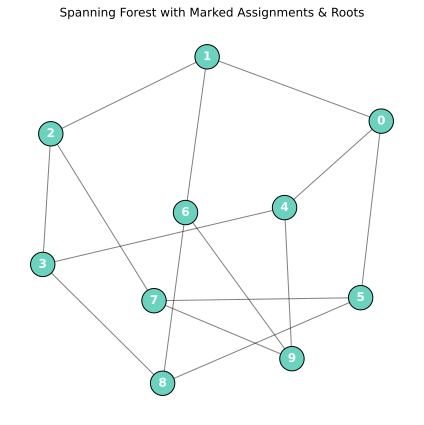

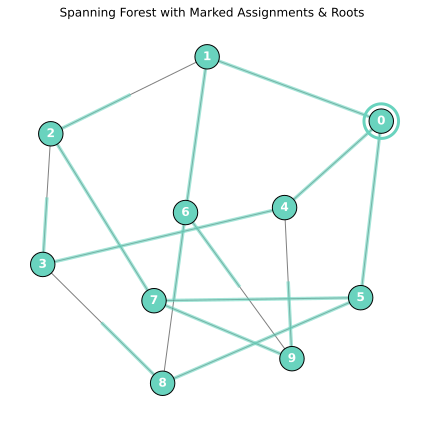

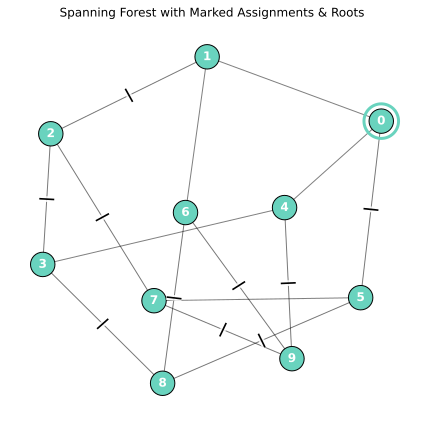

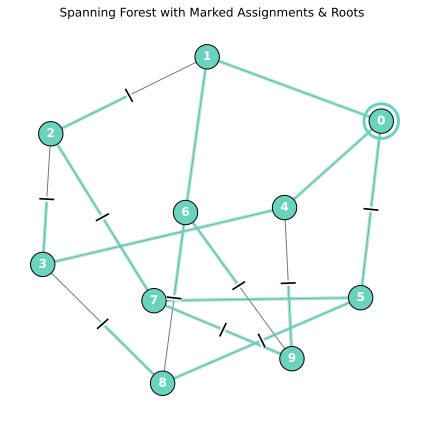

In [50]:
import networkx as nx

grf, forest, M, matchings = load_solution_triplet(10, 4, 1)
roots = find_min_height_roots(forest)

matchings = match_forest_leaves_to_marked_edges(grf, forest, M)
print(matchings)
roots = find_min_height_roots(forest)
empty: nx.Graph = grf.copy()
pos = nx.kamada_kawai_layout(grf)
empty.clear_edges()
draw_spanning_forest_solution(grf, empty, {}, {}, [], figsize=(6,6), pos=pos)
draw_spanning_forest_solution(grf, forest, {}, matchings, roots, figsize=(6,6), pos=pos)
draw_spanning_forest_solution(grf, empty, M, {}, roots, figsize=(6,6), pos=pos)
draw_spanning_forest_solution(grf, forest, M, matchings, roots, figsize=(6,6), pos=pos)

=== Starting Elegant Extraction (BFS) ===
Init Root 0 (Tree 0) -> Q0
  Node 0 -> Branch 10: Spawned CNOT Q0 -> Q1
  Node 0 -> Branch 1: Spawned CNOT Q0 -> Q2
  Node 0 -> Primary 4 (Inherits Q0)
  Mark on 10: Spawned CNOT Q1 -> Q3
  Node 10 -> Primary 5 (Inherits Q1)
  New flag initialised (1, 11): CNOT Q2 -> Q10
  Node 1 -> Primary 6 (Inherits Q2)
  New flag initialised (4, 15): CNOT Q0 -> Q11
  Node 4 -> Primary 3 (Inherits Q0)
  Node 5 -> Branch 7: Spawned CNOT Q1 -> Q4
  Node 5 -> Primary 16 (Inherits Q1)
  Node 6 -> Branch 17: Spawned CNOT Q2 -> Q5
  Node 6 -> Primary 18 (Inherits Q2)
  New flag initialised (3, 14): CNOT Q0 -> Q12
  Node 3 -> Primary 12 (Inherits Q0)
  Node 7 -> Branch 13: Spawned CNOT Q4 -> Q6
  Node 7 -> Primary 19 (Inherits Q4)
  Mark on 16: Spawned CNOT Q1 -> Q7
  Node 16 -> Primary 8 (Inherits Q1)
  New flag initialised (17, 8): CNOT Q5 -> Q13
  Node 17 serves as a sink point for Q5
  New flag initialised (18, 9): CNOT Q2 -> Q14
  Node 18 serves as a sink poin

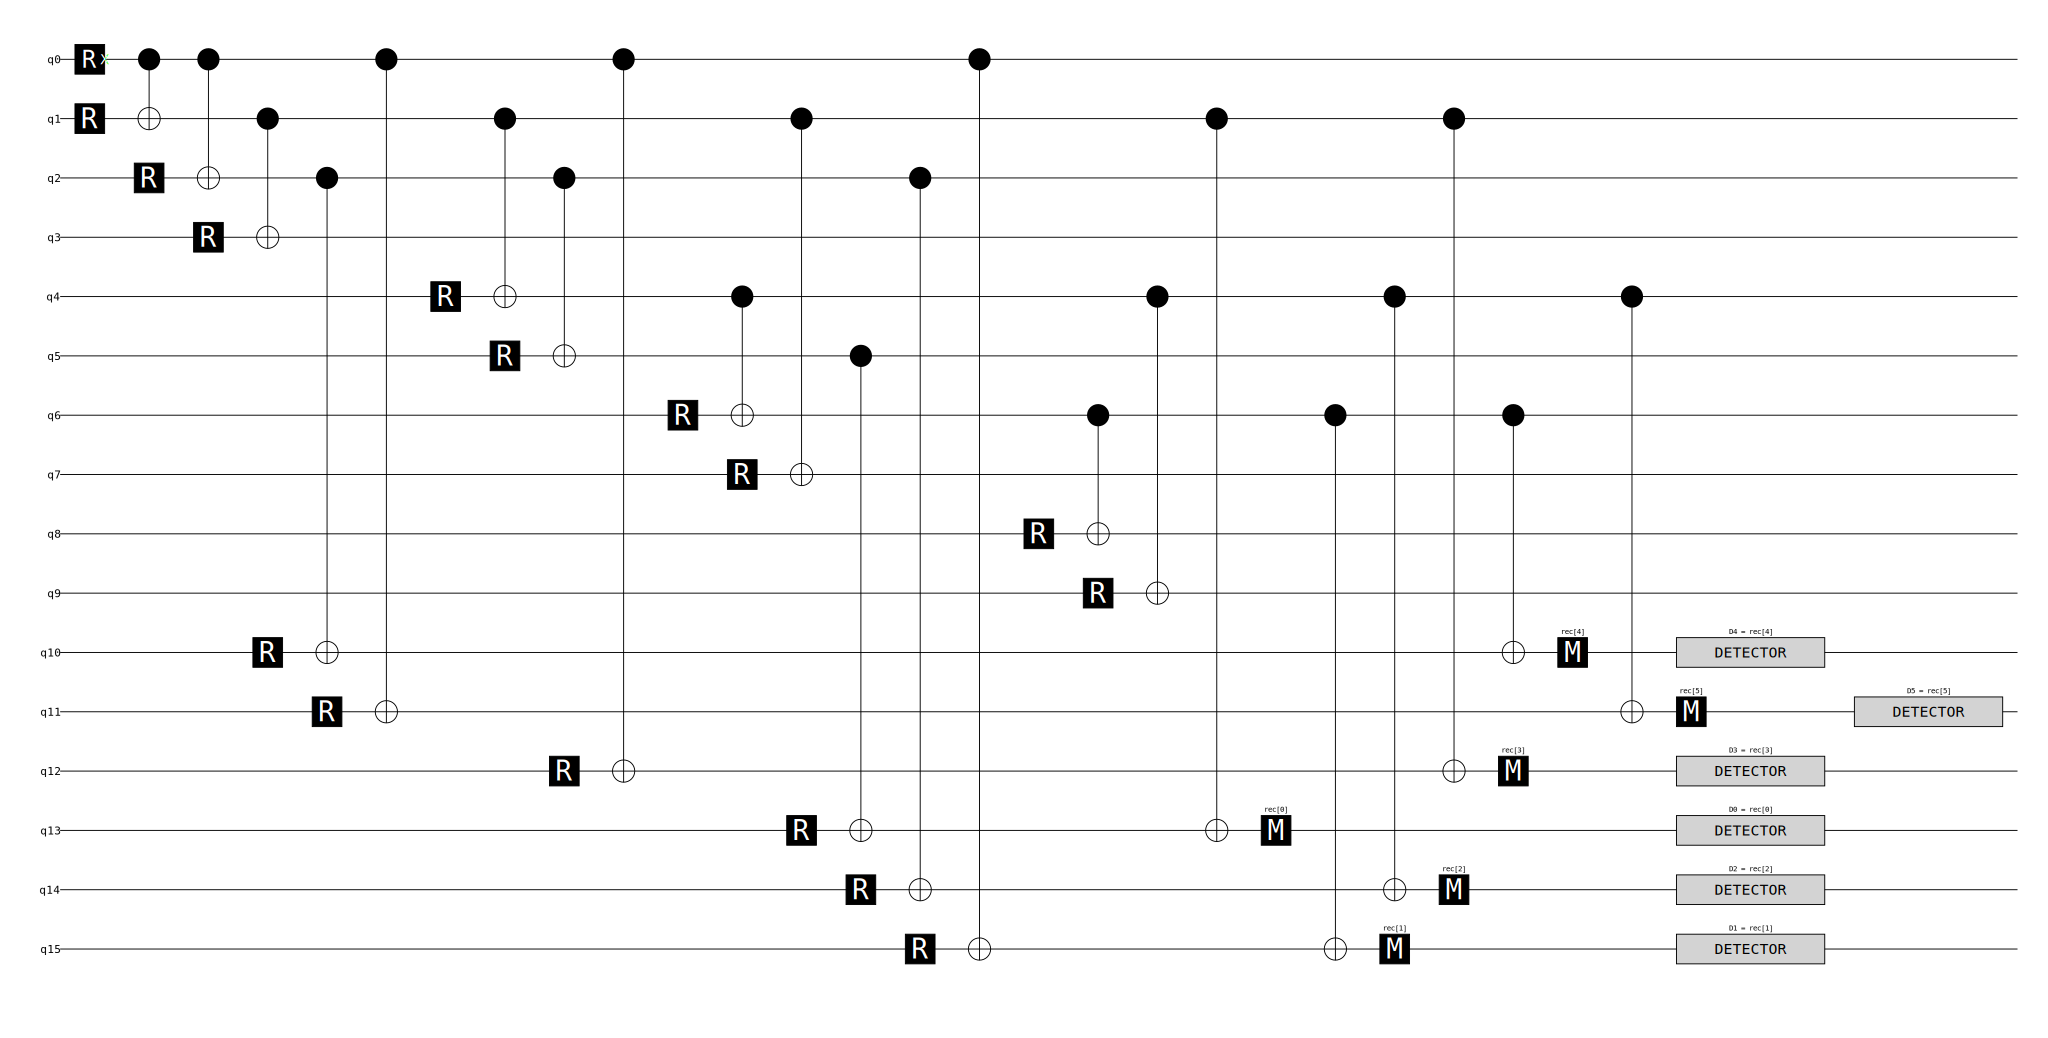

In [45]:
circ = extract_circuit_rooted(grf, forest, roots, M, matchings, verbose=True)
circ.diagram('timeline-svg')